# Mini Visualization Dashboard - Titanic Dataset

This notebook presents a comprehensive data visualization dashboard using the Titanic dataset. We'll explore passenger demographics, survival patterns, and key relationships through various visualizations.

## Overview

The Titanic dataset contains information about passengers aboard the RMS Titanic, including demographics, ticket class, fare, and survival status. This dashboard aims to uncover insights about factors that influenced survival rates.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Create images directory if it doesn't exist
os.makedirs('images', exist_ok=True)

print("Libraries imported successfully!")

Libraries imported successfully!


## Cleaning

Loading the dataset and handling missing values.

In [2]:
# Load Titanic dataset from local CSV (more reliable than seaborn download)
df = pd.read_csv('titanic.csv')

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst few rows:")
df.head()

Dataset shape: (891, 12)

Column names: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

First few rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Check for missing values
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
# Handle missing values
# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column (use errors='ignore' to avoid errors if column doesn't exist)
df = df.drop(columns=['Cabin'], errors='ignore')

# Verify no missing values remain in key columns
print("Missing values after cleaning:")
df.isnull().sum()

Missing values after cleaning:


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Features

Creating engineered features for deeper analysis.

In [5]:
# Create FamilySize feature: SibSp + Parch
df['FamilySize'] = df['SibSp'] + df['Parch']

# Create AgeGroup feature using pd.cut()
# Define age bins and labels
age_bins = [0, 12, 18, 30, 60, 100]
age_labels = ['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

# Display the new features
print("New features added: FamilySize, AgeGroup")
print("\nSample of new features:")
df[['Age', 'AgeGroup', 'SibSp', 'Parch', 'FamilySize']].head(10)

New features added: FamilySize, AgeGroup

Sample of new features:


,Age,AgeGroup,SibSp,Parch,FamilySize
0,22.0,YoungAdult,1,0,1
1,38.0,Adult,1,0,1
2,26.0,YoungAdult,0,0,0
3,35.0,Adult,1,0,1
4,35.0,Adult,0,0,0
5,28.0,YoungAdult,0,0,0
6,54.0,Adult,0,0,0
7,2.0,Child,3,1,4
8,27.0,YoungAdult,0,2,2
9,14.0,Teen,1,0,1


## Visualizations

Exploring the data through various charts and plots.

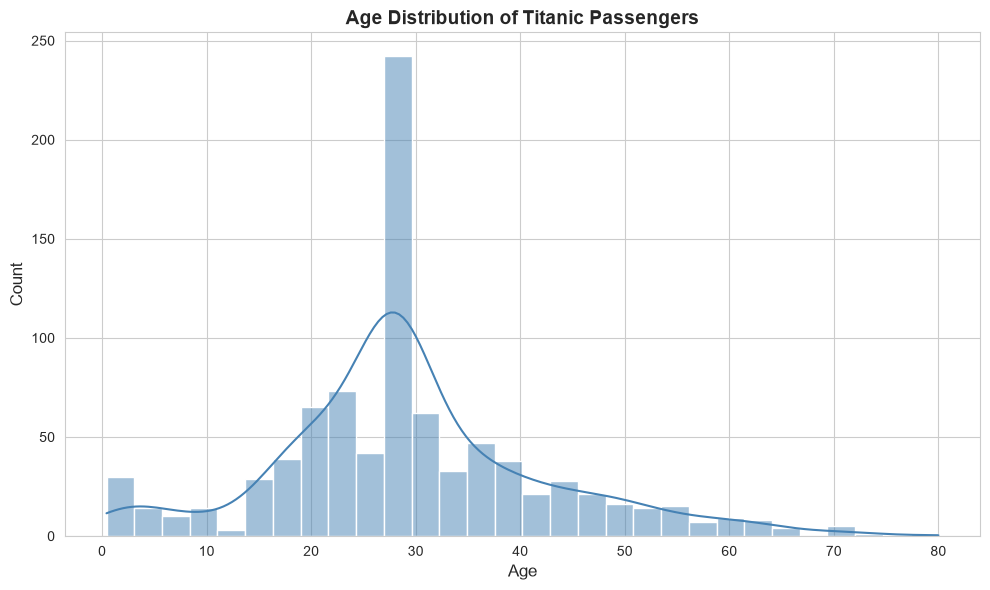

In [6]:
# Plot 1: Histogram of Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', kde=True, bins=30, color='steelblue')
plt.title('Age Distribution of Titanic Passengers', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig('images/age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

**Chart 1 Insight:** The age distribution shows a right-skewed pattern with most passengers between 20-40 years old. The KDE curve reveals a notable peak around 25-30 years, indicating young adults were the largest demographic group aboard the Titanic.

/var/folders/z_/wh1yyvts33j1nf_kczlxbg840000gn/T/ipykernel_36465/1342808462.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=survival_by_sex.index, y=survival_by_sex.values, palette='pastel')


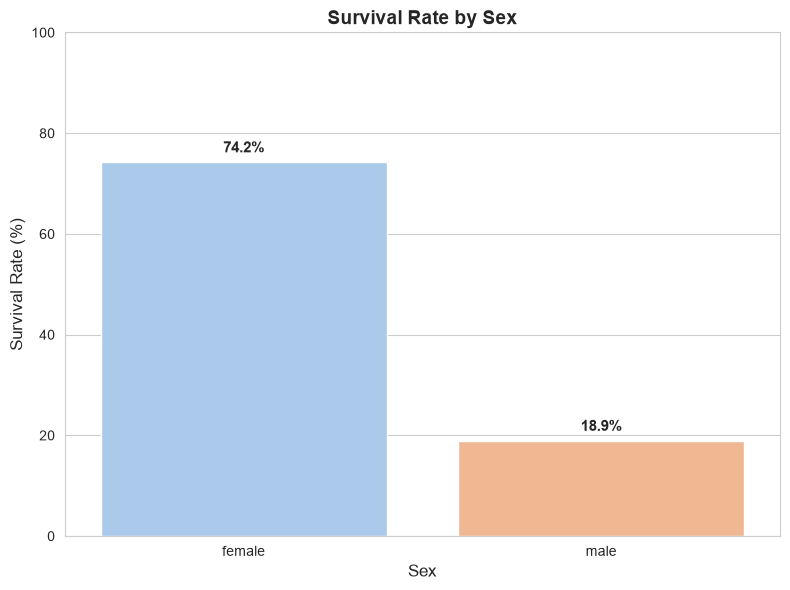

In [7]:
# Plot 2: Bar chart of Survival Rate by Sex
plt.figure(figsize=(8, 6))
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100
sns.barplot(x=survival_by_sex.index, y=survival_by_sex.values, palette='pastel')
plt.title('Survival Rate by Sex', fontsize=14, fontweight='bold')
plt.xlabel('Sex', fontsize=12)
plt.ylabel('Survival Rate (%)', fontsize=12)
plt.ylim(0, 100)
# Add value labels on bars
for i, v in enumerate(survival_by_sex.values):
    plt.text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('images/survival_by_sex.png', dpi=300, bbox_inches='tight')
plt.show()

**Chart 2 Insight:** Females had a dramatically higher survival rate (74.2%) compared to males (18.9%), highlighting the "women and children first" protocol followed during the evacuation. This 4x difference in survival rates is one of the most striking patterns in the dataset.

/var/folders/z_/wh1yyvts33j1nf_kczlxbg840000gn/T/ipykernel_36465/2518013270.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pclass', y='Fare', palette='Set2')


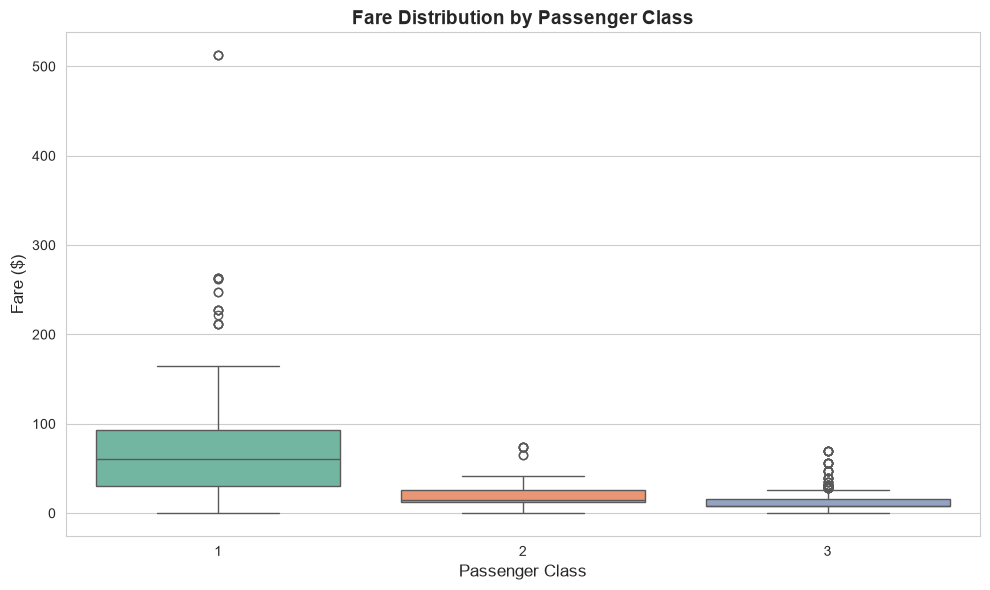

In [8]:
# Plot 3: Boxplot of Fare by Passenger Class
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Pclass', y='Fare', palette='Set2')
plt.title('Fare Distribution by Passenger Class', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Fare ($)', fontsize=12)
plt.tight_layout()
plt.savefig('images/fare_by_class.png', dpi=300, bbox_inches='tight')
plt.show()

**Chart 3 Insight:** First-class passengers paid significantly higher fares (median ~$60) with many outliers above $100, while third-class fares were much lower (median ~$10). The wide spread in first-class fares indicates substantial wealth inequality even within the upper class.

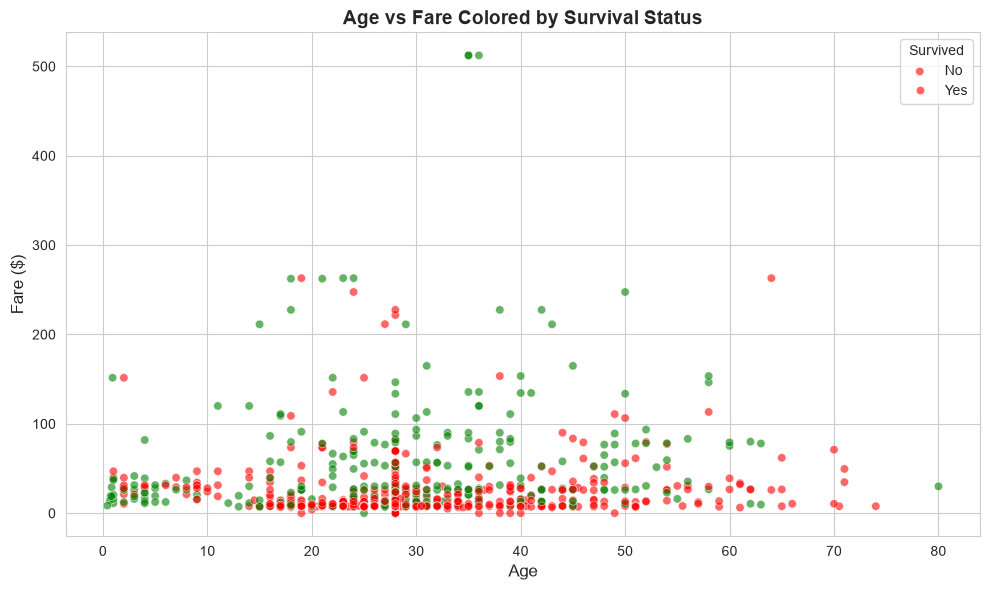

In [9]:
# Plot 4: Scatterplot of Age vs Fare, colored by Survived
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived', palette={0: 'red', 1: 'green'}, alpha=0.6)
plt.title('Age vs Fare Colored by Survival Status', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Fare ($)', fontsize=12)
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.tight_layout()
plt.savefig('images/age_vs_fare_survival.png', dpi=300, bbox_inches='tight')
plt.show()

**Chart 4 Insight:** The scatter plot reveals that higher-paying passengers (green points) had better survival rates, particularly among those who paid over $50. However, age alone doesn't show a clear survival pattern, suggesting fare/class was more influential than age in determining survival outcomes.

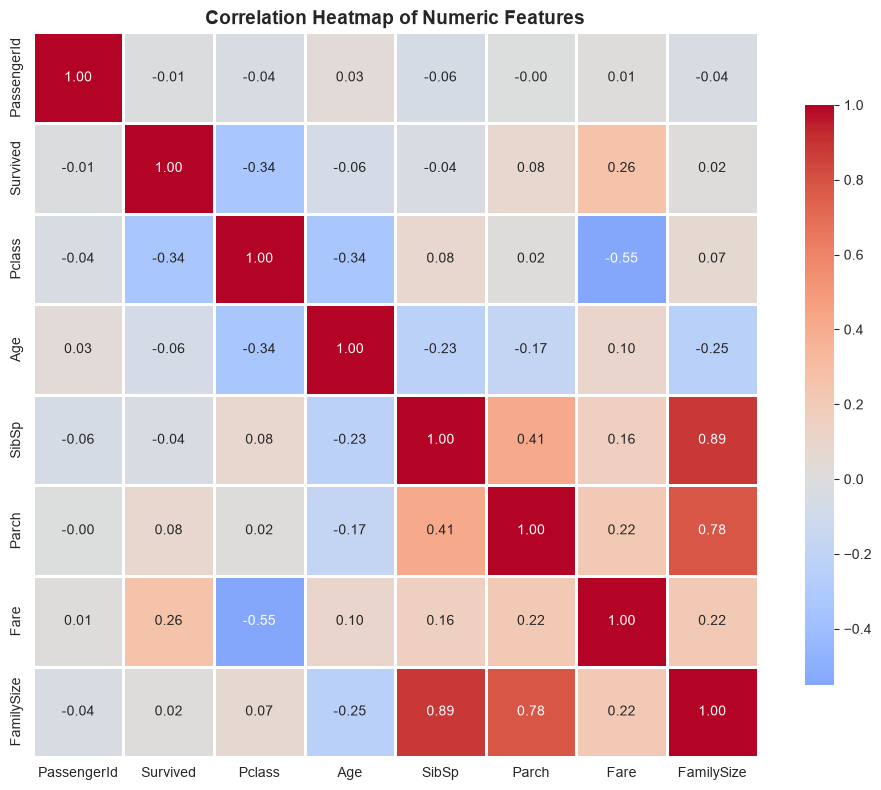

In [10]:
# Plot 5: Heatmap of correlations between numeric columns
plt.figure(figsize=(10, 8))
# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

**Chart 5 Insight:** The strongest correlation is between Pclass and Fare (-0.55), confirming that higher class numbers (lower class) paid less. Survival shows moderate positive correlation with Fare (0.26) and negative correlation with Pclass (-0.34), indicating wealthier passengers in higher classes had better survival chances.

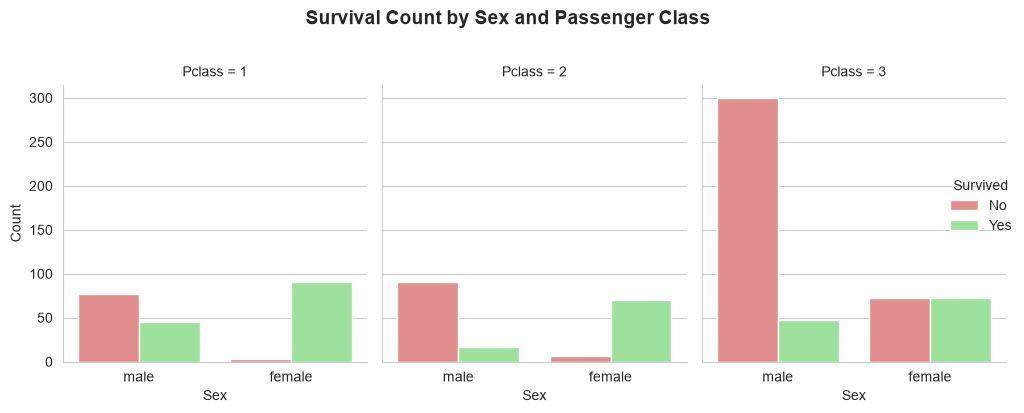

In [11]:
# Bonus Plot 6: Facet grid comparing Survival by Sex and Pclass
g = sns.catplot(data=df, x='Sex', hue='Survived', col='Pclass', 
                kind='count', palette={0: 'lightcoral', 1: 'lightgreen'},
                height=4, aspect=0.8)
g.fig.suptitle('Survival Count by Sex and Passenger Class', y=1.02, fontsize=14, fontweight='bold')
g.set_axis_labels('Sex', 'Count')
g._legend.set_title('Survived')
new_labels = ['No', 'Yes']
for t, l in zip(g._legend.texts, new_labels):
    t.set_text(l)
plt.tight_layout()
plt.savefig('images/survival_by_sex_class.png', dpi=300, bbox_inches='tight')
plt.show()

**Chart 6 Insight:** The facet grid reveals that first-class females had the highest survival rates, while third-class males had the lowest. This visualization confirms that both gender and class were critical factors—first-class women survived at much higher rates than third-class men, demonstrating intersectional privilege in the evacuation process.

## Insights

**Key Findings from the Dashboard:**

1. **Gender was the strongest predictor of survival** - Women survived at 4x the rate of men (74% vs 19%), reflecting the maritime evacuation protocol.

2. **Socioeconomic status mattered significantly** - First-class passengers, who paid higher fares, had substantially better survival rates than third-class passengers.

3. **Age distribution was right-skewed** - Most passengers were young adults (20-40 years), with fewer children and seniors aboard.

4. **Fare and class were strongly correlated** - Higher passenger class (lower Pclass number) correlated with higher fares, confirming the class-based pricing structure.

5. **Intersectional effects were pronounced** - First-class women had the best outcomes, while third-class men fared worst, showing how multiple factors compounded.

## Conclusion

This mini visualization dashboard successfully explored the Titanic dataset and revealed critical patterns in survival outcomes. The analysis demonstrates that social factors—particularly gender and socioeconomic class—played decisive roles in who survived the disaster. The visualizations provide clear, data-driven insights that align with historical accounts of the Titanic evacuation. This dashboard serves as a foundation for more advanced predictive modeling and deeper demographic analysis.